# Adding node data (labels)

In many applications, nodes in a spatial network carry additional information beyond their spatial location. These properties, commonly referred to as *node attributes* in network science, can describe characteristics of each node, such as its type, class, or any other associated metadata. Node attributes may be categorical or continuous (numeric), and they do not need to be available for every node in the network.

In this tutorial, we'll walk through how to add node labels to a spatial network. Node labels can be useful for identifying and analysing specific subsets of nodes, as well as for visualising different node populations.

We'll begin by loading a reference dataset containing point coordinates together with several categorical and continuous node labels.


In [1]:
import spacenet as sn
import numpy as np

# load in the example dataset 'sprial'
spiral_data = sn.datasets.load_dataset('spiral')

# output the dataframe to see some of the properties
spiral_data

,x,y,Random marker (categorical),Marker (categorical),Random marker (continuous),Marker (continuous)
0,705.221202,839.551553,A,A,0.077634,0.993924
1,623.482970,754.857152,B,B,-0.605651,-0.998640
2,413.758752,60.720287,A,A,0.820813,0.812924
3,668.320495,527.512054,A,A,0.391962,0.821566
4,21.976947,591.338045,B,C,-0.215937,0.331704
...,...,...,...,...,...,...
1154,65.871053,316.582439,A,C,0.412209,0.552758
1155,349.433537,435.757872,A,A,0.329032,0.789686
1156,227.878251,504.365859,B,A,-0.803192,0.648041
1157,593.403352,93.866045,A,C,0.033997,-0.573464


The dataframe contains the point coordinates (`x` and `y`) together with several additional columns of node labels. Let's first extract the coordinates and the categorical label, `Marker (categorical)`, into a format suitable for constructing a spatial network with SpaceNet.


In [2]:
# extract the point data
points = np.array([spiral_data['x'],spiral_data['y']]).T

# extract the categorical labels 
cat_labels = spiral_data['Marker (categorical)']

Now that we have the point coordinates and their corresponding labels in the same order, we can generate a spatial network and add the labels to its nodes using `add_node_labels()`.


In [3]:
# generate a spatial network
spatial_net = sn.utils.spatial_network_from_points(points,max_edge_distance=75)

# add the categorical labels to the network
sn.utils.add_node_labels(spatial_net,labels=cat_labels,node_label_name='demo label (cat)')

# check the nodes have been added 
sn.utils.print_network_properties(spatial_net)


------------------
Network properties
------------------
Number of nodes: 1159
Number of edges: 3165
Edge weight names: ['Distance', 'Inverse Distance']
Node label names: ['position', 'demo label (cat)']
------------------


The node labels have now been added to the spatial network. We can visualise them by colouring the nodes according to their label values using the `node_label_name` parameter in `plot_spatial_network()`.


(<Figure size 640x480 with 2 Axes>, <Axes: >)

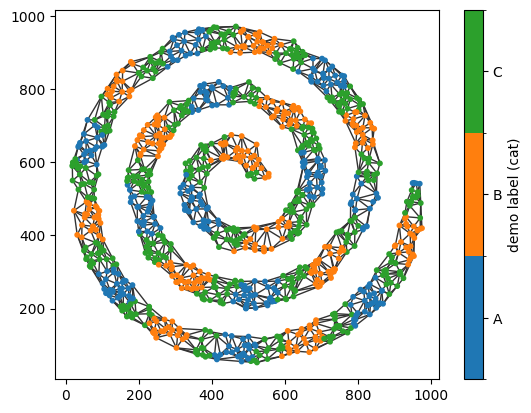

In [4]:
# plot the spatial network with nodes colored by the demo labels 
sn.utils.plot_spatial_network(spatial_net,node_label_name='demo label (cat)')

The nodes are now coloured according to their categorical labels, revealing the sequence of labels (`A`, `B`, and `C`) along the spiral.

The same workflow also applies to continuous labels. Let's demonstrate this by extracting the `Marker (continuous)` values from the dataframe and adding them to the spatial network.


In [5]:
# extract the categorical labels 
cont_labels = spiral_data['Marker (continuous)']

# add the categorical labels to the network
sn.utils.add_node_labels(spatial_net,labels=cont_labels,node_label_name='demo label (cont)')

# check the nodes have been added 
sn.utils.print_network_properties(spatial_net)

------------------
Network properties
------------------
Number of nodes: 1159
Number of edges: 3165
Edge weight names: ['Distance', 'Inverse Distance']
Node label names: ['position', 'demo label (cat)', 'demo label (cont)']
------------------


Now we have the additional node label 'demo label (cont)' and we can visualise this as before.

(<Figure size 640x480 with 2 Axes>, <Axes: >)

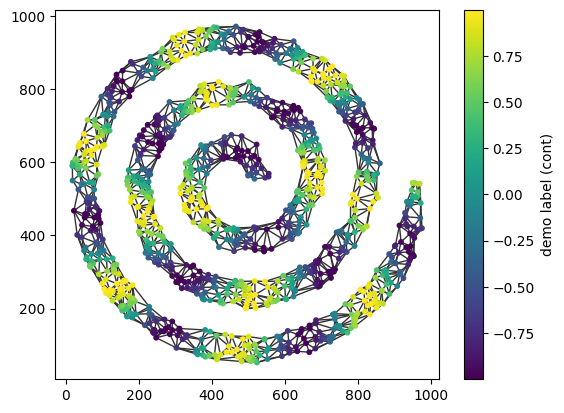

In [6]:
# visualise the spatial network with continuous labels 
sn.utils.plot_spatial_network(spatial_net,node_label_name='demo label (cont)')

Notice that `plot_spatial_network()` automatically distinguishes between categorical and continuous node labels, selecting an appropriate colouring scheme for each. For this example, the default `viridis` colormap is not ideal for the continuous data, but it can easily be replaced with a diverging colormap using the plotting options.

In some applications, labels are only available for a subset of nodes. This can be handled by specifying the node IDs to associate with the labels using the `nodes` parameter in `add_node_labels()`. In the example below, we'll add a new label only to the nodes with the `Marker A` category.


(<Figure size 640x480 with 2 Axes>, <Axes: >)

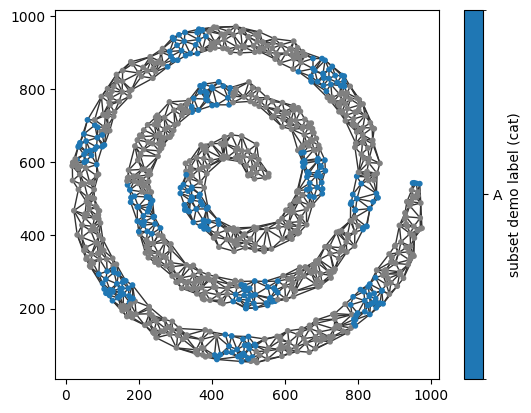

In [7]:

# getting a subset of the labels and the node IDs associated with these labels
cat_labels_subset = cat_labels[cat_labels=='A']
nodes_with_A = np.where(cat_labels=='A')[0]

# add the categorical labels to the network to only a subset
sn.utils.add_node_labels(spatial_net,labels=cat_labels_subset,node_label_name='subset demo label (cat)',nodes=nodes_with_A)

# plot the spatial network with the subset labels
sn.utils.plot_spatial_network(spatial_net,node_label_name='subset demo label (cat)')

Nodes without an associated label are displayed using the default grey colour.

In this tutorial, we've shown how to add both categorical and continuous node labels to a spatial network. Visualising these labels provides a convenient way to verify that they have been assigned correctly, and they can subsequently be used to query, filter, and analyse specific subsets of nodes.